### Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
# Imports
import sys, glob, json
from pathlib import Path
from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent, SaliencyMapMethod, CarliniL2Method

sys.path.append(str(Path.cwd().parents[2]))

from utils.functions import get_windowed_data
from utils.notebook import get_model_classifier, clean_data_test, adv_test, FilenameLoader, get_filename_from_path

### Load Model and Data

In [9]:
## Inputs
data_name = FilenameLoader.rand_pos()[1]

checkpoint_folder= f"../../../saved_models/decen/init-test-randpos/*"
data_file = f"../../../data/{data_name}"
save_path = "../final_data/randpos"

In [10]:
## Load data
# Load data
(x_train, y_train), (x_test, y_test), fed_dataset, scaler = get_windowed_data(data_file, 
                                                                      normalize=True, 
                                                                      train_perc=80)

In [12]:
## Test clean
vehicles_ckpts = glob.glob(checkpoint_folder)

for i in range(len(vehicles_ckpts)):
    print("\n")
    checkpoint_file = vehicles_ckpts[i]
    model, classifier = get_model_classifier(checkpoint_file)

    filename = get_filename_from_path (checkpoint_file)
    out = clean_data_test(model = model, classifier = classifier, # model information
                x_test=x_test, y_test=y_test, # data information
                checkpoint_file=checkpoint_file, data_file=data_file, # to save in json
                save_path="../data-test", filename=f"clean_{filename}.json", # saving information
                save_results=False
                ) 
    print(checkpoint_file, "PASS" if out["wrapper"]["f1"] > 0.8 else "FAIL")

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/reu/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.




Checkpoint path exists!


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


save=False, Metrics not saved
Metrics {'noWrapper': {'accuracy': 0.972798018818023, 'recall': 0.9088535203668735, 'precision': 0.9995460816163054, 'f1': 0.9520448171356312, 'falseNegativeRate': 0.09114647963312651, 'falsePositiveRate': 0.00017445042415397245, 'TP': 336912, 'TN': 876887, 'FP': 153, 'FN': 33788}, 'wrapper': {'accuracy': 0.972798018818023, 'precision': 0.9995460816163054, 'recall': 0.9088535203668735, 'f1': 0.9520448171356312, 'falseNegativeRate': 0.09114647963312651, 'falsePositiveRate': 0.00017445042415397245, 'TP': 336912, 'TN': 876887, 'FP': 153, 'FN': 33788}, 'files': {'checkpointFile': '../../../saved_models/decen/init-test-randpos/vehicle_119_model.ckpt', 'dataFile': '../../../data/RandomPos_0709.csv'}}
../../../saved_models/decen/init-test-randpos/vehicle_119_model.ckpt PASS


Checkpoint path exists!


KeyboardInterrupt: 

### Adversarial Tests

In [ ]:

for eps_i in range(1, 10, 1):
    eps = float(eps_i/100)
    for i in range(len(vehicles_ckpts)):
        checkpoint_file = vehicles_ckpts[i]
        model, classifier = get_model_classifier(checkpoint_file)

        save_path = f"../data-test/randpos/fgsm/eps-{eps}"
        filename = f"adv_eps_{eps}_{get_filename_from_path(checkpoint_file)}.json"
        adv_test(classifier, x_test, y_test, 
                 checkpoint_file, data_file,
            end_index = len(y_test.numpy()),
            path = save_path,
            filename=filename,
            in_classifier=classifier,
            Attack=FastGradientMethod,
            eps=eps,
            targeted=False
            )

0.01
0.02
0.03
0.04
0.05
0.06
0.07
0.08
0.09
0.1
0.11
0.12
0.13
0.14
0.15
0.16
0.17
0.18
0.19
0.2
0.21
0.22
0.23
0.24
0.25
0.26
0.27
0.28
0.29
0.3


In [7]:

# vehicles = glob.glob("../data-test/randpos/benign/*")
vehicles = glob.glob("../data-test/randpos/fgsm/*")

f1_scores = []

for veh_file in vehicles:
    with open(veh_file, "r") as veh:
        veh_json = json.load(veh)
        # f1_scores.append(veh_json["wrapper"]["f1"])
        f1_scores.append(veh_json["metrics"]["f1"])

f1_avg = sum(f1_scores) / len(f1_scores)

f1_avg

0.5937189128614161

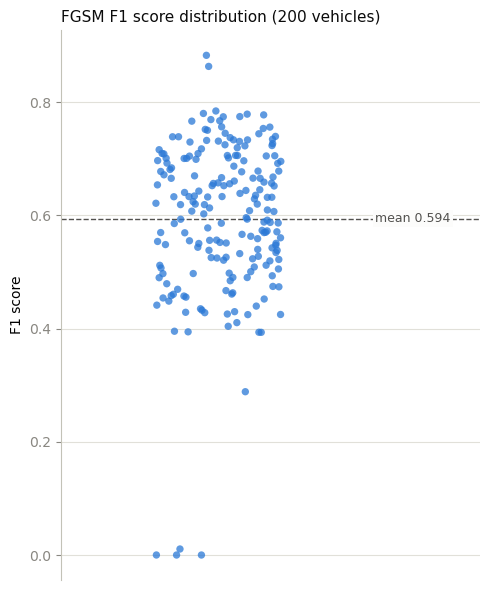

In [8]:
# Point plot of the per-vehicle F1 scores, to see the distribution behind f1_avg
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(5, 6))

rng = np.random.default_rng(0)
jitter = rng.uniform(-0.12, 0.12, size=len(f1_scores))

ax.scatter(jitter, f1_scores, s=28, facecolor="#2a78d6", edgecolor="none", alpha=0.75, zorder=3)

mean_f1 = float(np.mean(f1_scores))
ax.axhline(mean_f1, color="#52514e", linestyle="--", linewidth=1, zorder=2)
ax.text(0.3, mean_f1, f"mean {mean_f1:.3f}", color="#52514e", fontsize=9,
        va="center", ha="left",
        bbox=dict(facecolor="#fcfcfb", edgecolor="none", pad=1.5))

ax.set_xlim(-0.3, 0.5)
ax.set_xticks([])
ax.set_ylabel("F1 score")
ax.set_title(f"FGSM F1 score distribution ({len(f1_scores)} vehicles)",
             fontsize=11, color="#0b0b0b", loc="left")

for spine in ("top", "right", "bottom"):
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#c3c2b7")
ax.tick_params(colors="#898781")
ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()